## 군집화 예습 정리

### 목차
1. 군집화
2. 군집화를 위한 데이터 준비
3. 군집화 알고리즘
4. 군집화 평가 방법

---

### 1. 군집화

#### 1-1. **머신러닝: 비지도 학습**

- **머신러닝**  
: 컴퓨터가 스스로 학습할 수 있도록 돕는 알고리즘이나 기술을 개발하는 분야
    1) 지도 학습: 정답이 있는 데이터 사용
    2) 비지도 학습: 정답이 없는 데이터 사용 <- 군집화

- **비지도 학습**  
: 데이터 자체에 내재된 구조를 파악해서 학습  
    → 모델의 성능을 명확히 측정할 수 X
    - 목표 자체가 명확하지 않고, 데이터에서 새로운 특성을 찾는 등 목적 수행에 적합

- 비지도 학습이 적합한 경우
    - 패턴이 아직 알려지지 않은 경우
    - 패턴이 계속해서 변하는 경우
    - 열린 문제를 해결하고 지식을 일반화해야 하는 경우  
    ex) 고객 세그먼트 분석, 이상 거래 탐지, 자연어 처리

#### 1-2. 군집화란?

- **군집화**  
: 데이터를 비슷한 특성을 가진 그룹으로 나누는 기법

- 군집 (cluster)  
: 유사한 데이터들의 집합

- 군집화의 목표
    - 응집도 최대화 (같은 군집)
    - 분리도 최대롸 (다른 군집)

#### 1-3. 군집화 과정

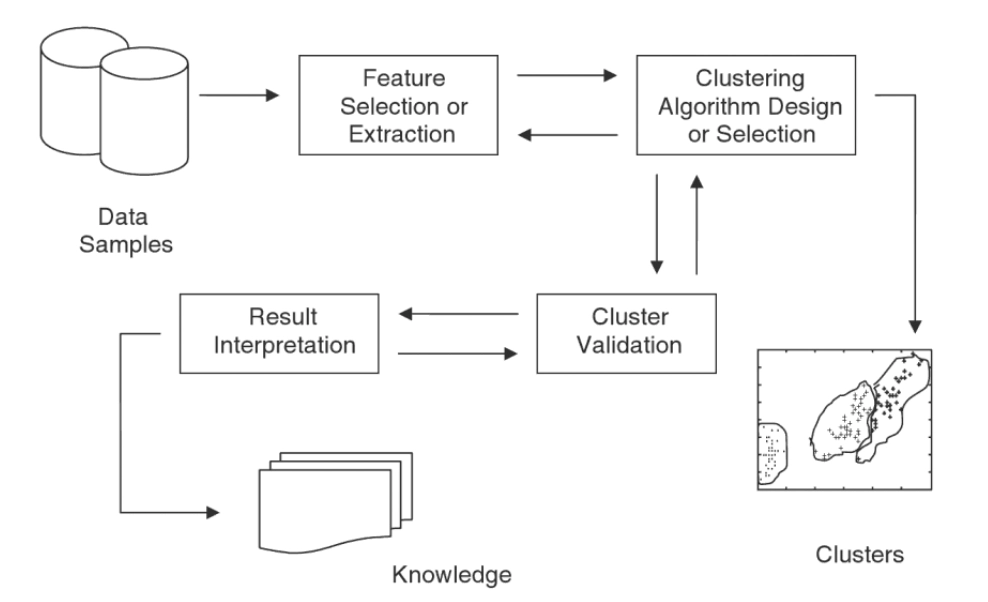

1) 피처 선택 또는 추출 
2) 군집화 알고리즘 선택
3) 군집 유효성 검증
4) 결과 해석  
→ 반복

---

### 2. 군집화를 위한 데이터 준비

#### 2-1. 군집화 주요 고려사항

1) 변수 유형 이해
    - 군집화에 사용될 피처의 종류와 특성 이해
    - 명목형 / 연속형

2) 거리 / 유사도 정의와 측정
    - 거리, 유사도 기반 그룹 형성
    - 변수 유형에 따라 적합한 거리 측정 방식 다름

3) 차원 축소
    - 변수가 많아질수록 모델이 복잡해지고, 효율성과 성능 떨어짐 → 축소

#### 2-2. 변수 유형 이해

1) 연속형 변수  
    - 거리 측정: 유클리디안 거리, 맨하탄 거리
    - 적합한 알고리즘: K-means, 계층적 군집화
    - 스케일링 필수

2) 명목형 변수
    - 거리 측정: 해밍 거리, 자카드 거리
    - 적합한 알고리즘: K-modes, 계층적 군집화
    - 처리 방법: 원-핫 인코딩 또는 더미 변수 변환

3) 혼합형 변수
    - 연속형 + 명목형
    - 거리 측정: Gower distance
    - 적합한 알고리즘: K-prototypes, Gower distance 기반 계층적 군집화
    - 처리 방법: 거리 함수 조합

- `거리 측정 및 알고리즘 선택 기준`

1) 거리 계산 기준: "빼기"가 되는가?

| 변수 유형 | 순서 | 간격 의미 | 빼기 여부 | 거리 측정 |
| --- | --- | --- | --- | --- |
| **연속형** | O | O | 빼기 OK | 유클리디안, 맨하탄 거리 |
| **명목형** | X | X | 빼기 불가 (같다 / 다르다만 셈) | 해밍, 자카드 거리 |

    - 혼합형: 변수별로 다른 기준을 쓰고 결과 가중평균 (Gower distance)

2) 알고리즘 고르는 기준: "평균"을 낼 수 있는가?
    - K-means: 군집의 중심을 평균으로 계산 → 연속형 변수에만 적합
    - K-modes: 평균 대신 최빈값으로 명목형 데이터 처리
    - K-prototypes: 연속형에 평균, 명목형엔 최빈값

- 계층적 군집화
    - 장점: 중심점 계산 없이 데이터 간 거리 표만으로 작동
    - 단점: 데이터 규모가 커지면 메모리와 연산 시간이 폭증함 (소규모 데이터에 적합)

- 스케일링의 필요성  
→ 연속형 변수 사용 시 필수

#### 2-3. 거리 / 유사도 정의와 측정 

- **거리 측정 방법**  
: 데이터 간 유사성 / 비유사성을 수치로 계산하는 방법

1) 유클리디안 거리
    - 가장 일반적
    - 직선 거리 의미
    - K-means에서 사용

$$
d(\mathbf{x}, \mathbf{y}) = \sqrt{\sum_{i=1}^n (x_i - y_i)^2}
$$

2) 맨하탄 거리
    - 각 차원의 차이의 절댓값의 합
    - 이상치에 덜 민감

$$
d(\mathbf{x}, \mathbf{y}) = \sum_{i=1}^n |x_i - y_i|
$$

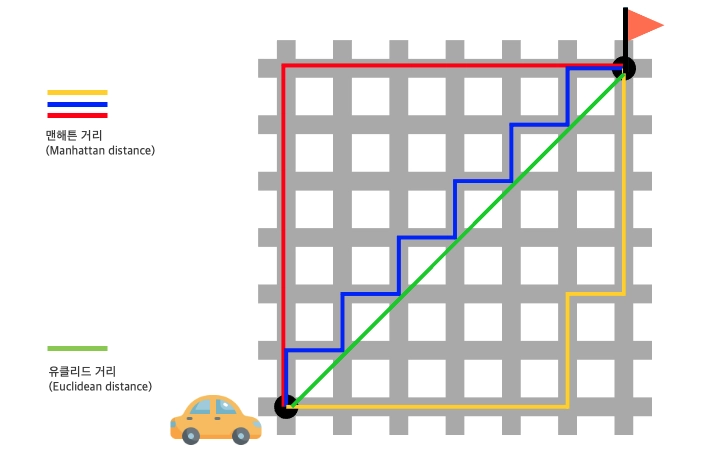

3) 코사인 유사도
    - 벡터 간 각도 측정
    - 덱스트 데이터나 고차원 데이터에 효과적

$$
\text{similarity} = \frac{\mathbf{x} \cdot \mathbf{y}}{||\mathbf{x}|| \times ||\mathbf{y}||}
$$

#### 2-4. 차원 축소

- **차원의 저주**  
: 피처 공간이 너무 커서 거리 공간 알고리즘이 데이터를 효과적으로 훈련할 수 없는 현상  
→ 분별력 감소

- `왜 분별력이 사라지는가?`
    1) 공간은 늘어나지만 데이터는 그대로
    2) 가까운 점과 먼 점의 차이가 사라짐 → 분별력 상실
    3) 상관 없는 피처 → 노이즈  
    → 차원 축소

- **차원 축소**  
: 변수의 개수를 줄이는 것
    - 목표: 노이즈는 줄이되 핵심 정보는 지키기
    - 선형 투영: 고차원 공간에서 저차원 공간으로 선형적으로 데이터를 투영
    ex) 주성분 분석 (PCA)
    - 매니폴드 학습 (비선형 차원 축소): 유클리드 거리가 아닌 데이터 포인트들 사이의 곡선 거리를 고려하며 학습

- **PCA**
    - 목적: 가장 분산이 큰 방향을 찾고, 그 방향을 기준으로 데이터를 투영하여 차원을 줄이는 것
    - 분산 최대한 보존
    - 상관관계가 높은 피처들을 결합해, 상관관계가 없는 더 적은 수의 피처로 데이터 표현
    - 새로 파생된 성분 = 주성분

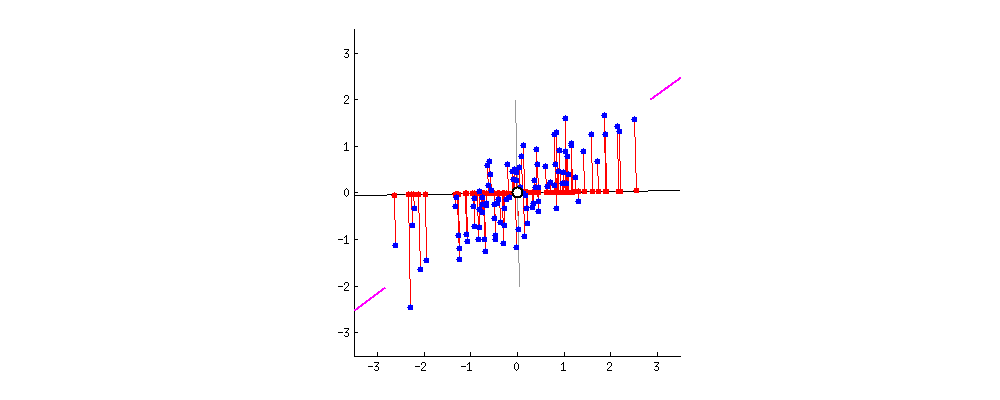

- PCA 코드
    - `X_scaled = StandardScaler().fit_transform(X)` #모든 피처를 평균 0, 분산 1로
    - `pca = PCA().fit(X_scaled)` #n_components 없이 학습 → 주성분을 전부 구함
    - `print(pca.explained_variance_ratio_)` #각 주성분이 설명하는 분산 비율 출력

- PCA 주의사항
    - 데이터 표준화 필수
    - 결측값 처리
    - 주성분 직관적 해석 어려움
    - 차원 축소 과정에서의 정보 손실

---

### 3. 군집화 알고리즘

#### 3-1. 계층적 군집화  

- **계층적 군집화**  
: 데이터를 둘씩 묶어 나가며 데이터가 언제 묶였는지를 나무 형태의 다이어그램으로 기록하는 군집화 방법
    - 클러스터링이 종료된 후 원하는 군집의 개수를 선택할 수 있음
    - 상향식 - 응집형 계층적 군집화: 각 샘플이 독립적 클러스터 → 하나만 남을 때까지 가까운 클러스터 병합
        1) 거리 행렬 계산
        2) 단일 클러스터 시작
        3) 가까운 두 클러스터 병합
        4) 거리 행렬 업데이트
        5) 3, 4 반복
    - 하향식 - 분리형 계층적 군집화: 하나의 클러스터 → 유사성 낮은 데이터를 작은 클러스터로 나눔

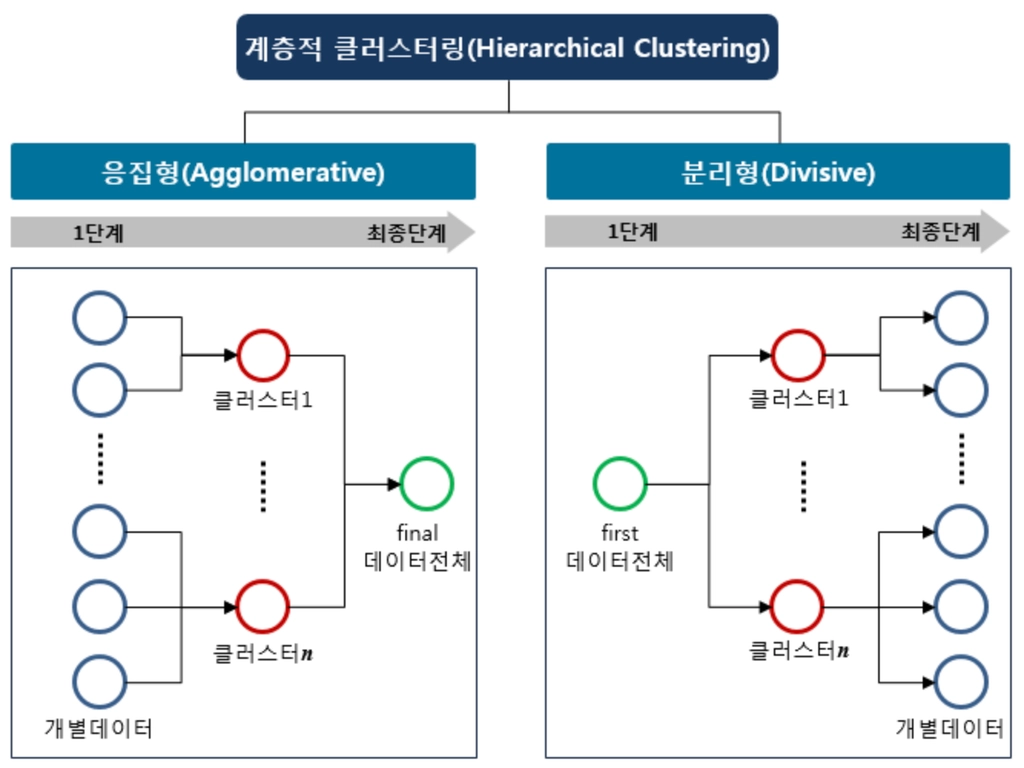

- 덴드로그램  
: 데이터를 병합해가는 과정을 시각적으로 나타내는 나무 형태의 다이어그램
    - 수직축 높이 = 두 군집이 병합될 때의 군집 간 거리

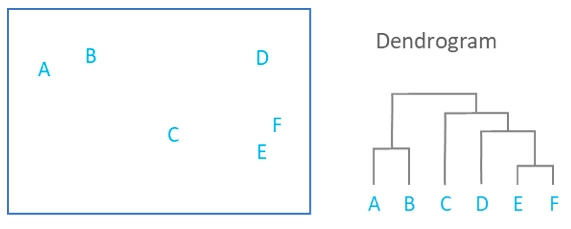

- `6가지 연결 방법`

1) Single linkage (단일 연결법 / 최단 연결법)  
: 군집 간 가장 가까운 두 점 간 거리
    - 고립된 군집 찾기 중점
    - 이상치에 취약

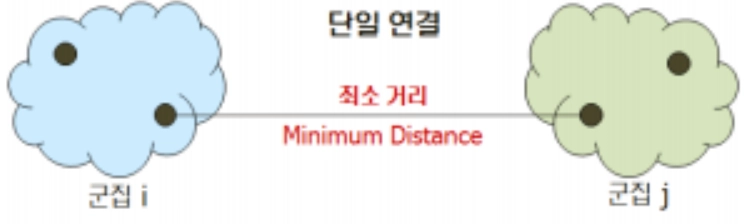

2) Complete linkage (완전 연결법 / 최장 연결법)  
: 군집 간 가장 먼 두 점 간 거리
    - 군집들의 내부 응집성 중점
    - 이상치에 취약

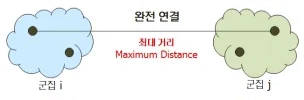

3) Average linkage (평균 연결법)  
: 군집 간 모든 점 쌍 사이 거리의 평균
    - 이상치에 덜 민감
    - 계산량 많음

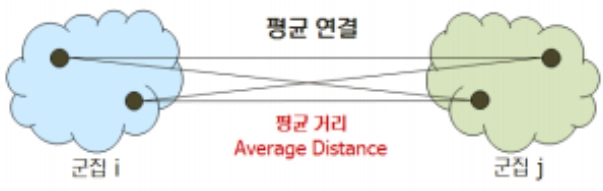

4) Centroid Method (중심 연결법)  
: 각 군집 중심점 간 거리
    - 시간 오래 소요
    - 덴드로그램에서 inversion 발생 가능

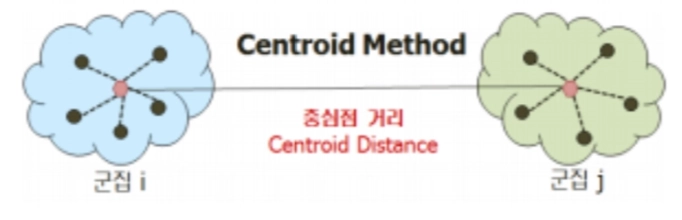

5) Median (중앙 연결법)  
: 두 군집 중앙값 사이 거리
    - 극단값에 영향을 덜 받음
    - 기하학적 구조 파악 어려움

6) Ward's Procedure (Ward 연결법)  
: 군집 내 SSE 가장 적게 증가하도록 병합

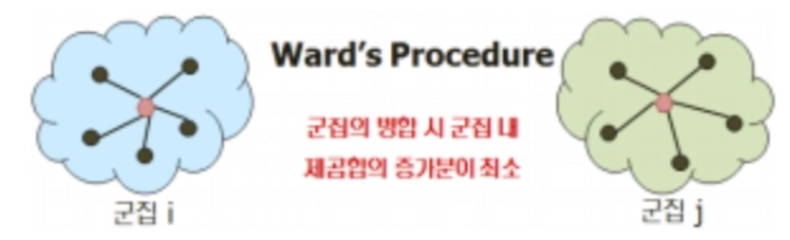

- `덴드로그램 읽기`  
→ 가로선이 끊는 세로선 개수 = 군집 개수

- 계층적 군집화 장단점
    - 장점
        - k 미리 정하지 않아도 됨
        - 데이터 전체 구조 확인 가능
        - 어떤 유형의 데이터에도 적용 가능
        - 결과 항상 같음
    - 단점
        - 느리고 메모리 많이 먹음
        - 한 번 합치면 되돌릴 수 x
        - 이상치에 민감
        - 사람이 정하는 자르는 높이

#### 3-2. k-means

- **k-means**  
: 각 그룹의 중심점과의 거리가 가장 가까운 데이터끼리 묶는 알고리즘

- 단계

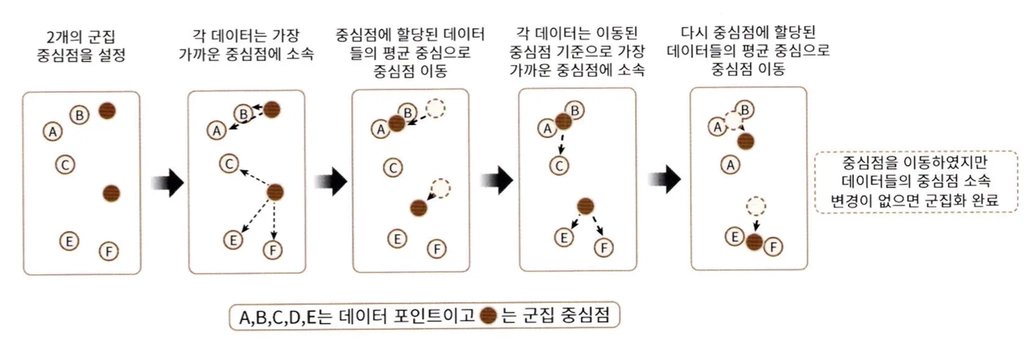

- k-means 장단점
    - 장점
        - 직관적
        - 구현 쉬움
    - 단점
        - 초기 centroid에 민감
        - k 결정 어려움
        - 아웃라이어에 민감
        - 기하학적인 모양 파악 어려움

- **엘보우 방법**  
: SSE를 바탕으로 최적 클러스터 개수 k를 추정하는 방법

#### 3-3. DBSCAN

- **DBSCAN**  
: 밀도를 기준으로 만족하는 데이터만 군집에 포함시키는 알고리즘
    - 이상치에 덜 민감
    - 특정 거리 내에선 가장 밀도 높은 군집으로

- 단계

1) 샘플 분류
    - 핵심 샘플
    - 경계 샘플
    - 잡음 샘플

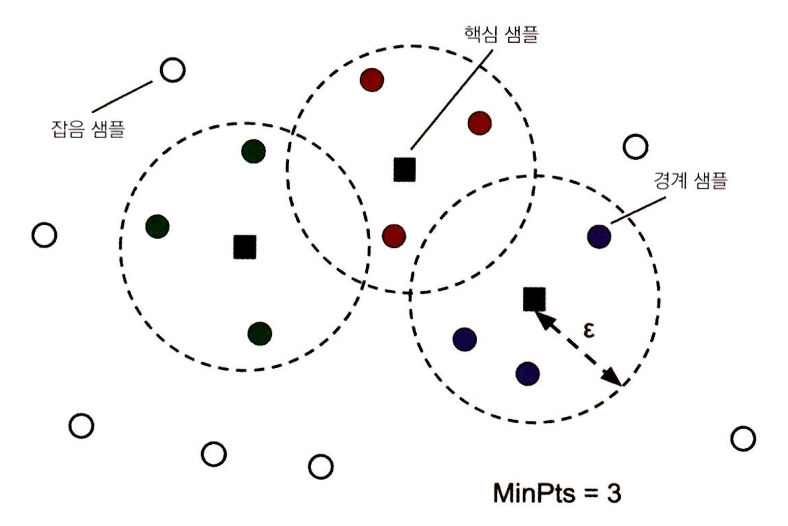

2) 클러스터 생성

3) 경계 샘플 할당

- DBSCAN 장단점
    - 장점
        - 기하학적 분포도 잘 처리
        - 이상치에 덜 민감
        - 모든 샘플 클러스터에 할당 x
    - 단점
        - eps와 min_samples 설정에 많은 영향 받음
        - 느림
        - 밀도가 다른 군집은 잘 잡지 못함 (낮은 쪽 노이즈로 버림)
        - 차원의 저주 영향

#### 3-4. GMM

- **Gaussian Mixture Model (GMM)**  
: 데이터가 여러 다른 모양의 가우시안 분포로 구성되었다고 가정하고, 각 분포를 클러스터로 인식하는 방법
    - 모델 기반 군집화
    - 여러 확률 분포의 혼합으로 모델링
    - 데이터 생성 메커니즘까지 모델링

- 과정

1) 주어진 전체 데이터셋 분포를 확인

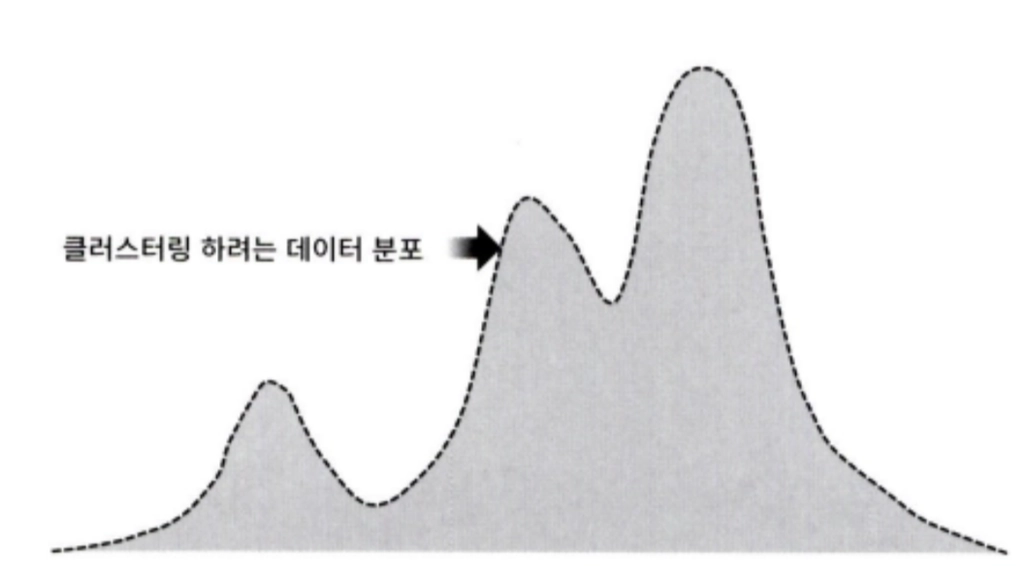

2) 서로 다른 정규분포 형태의 확률 분포 곡선으로 구성되어 있다고 가정

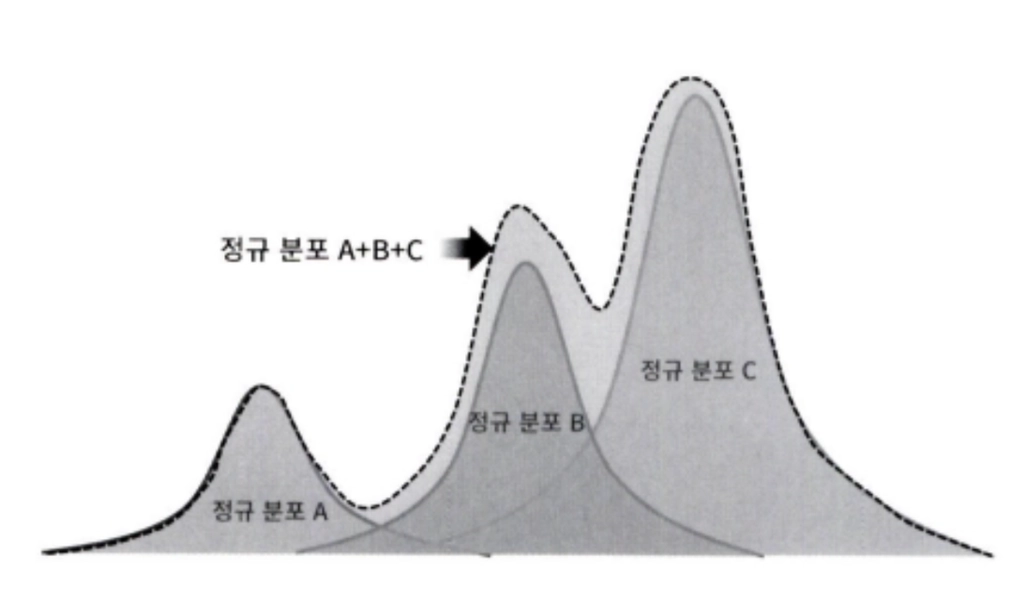

3) 정규분포 곡선 추출 → 데이터가 속하는 군집 결정

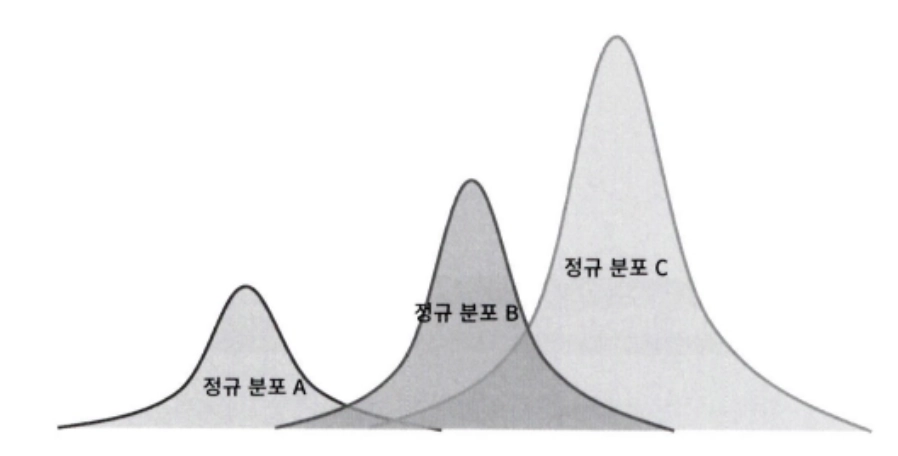

--- 

### 4. 군집화 평가 방법

#### 4-1. 외부 평가와 내부 평가

1) 외부 평가
- 정답 레이블 있는 경우
- 군집화 결과와 실제 레이블 유사도 평가 (ARI)

2) 내부 평가
- 정답 레이블 없는 경우
- 군집 내 응집도 / 군집 간 분리도 기반
- 알고리즘별 지표: k-means는 SSE 최소화, GMM은 로그 우도 최대화
- 범용 지표: 실루엣 계수, 던 지수

#### 4-2. 실루엣 계수

- **실루엣 계수**  
: 클러스터 내 샘플들이 얼마나 조밀하게 모여 있는지를 측정하는 도구

$$
s^{(i)} = \frac{b^{(i)} - a^{(i)}}{\max \left\{ b^{(i)}, a^{(i)} \right\}}
$$

    - 응집도 $a^{(i)}$, 분리도 $b^{(i)}$

- 해석

| 조건 | 계수 값 | 평가 |
|---|---|---|
| **분리도 > 응집도** | 1에 가까움 | **군집화가 잘 됨** |
| **분리도 = 응집도** | 0에 가까움 | 분리 명확하지 않음 |
| **분리도 < 응집도** | -1에 가까움 | **군집화가 잘못됨** |

    - `0.5 이상이면 쓸만함, 0.7 이상이면 잘 됨`

#### 4-3. Dunn Index

- **Dunn Index**  
: 클러스터 간 분리도와 클러스터 내 응집도의 비율 지표

$$
\text{Dunn Index} = \frac{\min\limits_{i \ne j} \; d(C_i, C_j)}{\max\limits_{1 \le k \le K} \; \delta(C_k)}
$$

    - 응집도 $delta(C_k)$, 분리도 $d(C_i, C_j)$

- 해석
    - 값이 클수론 좋은 군집화
    - 0 이상
    - 상한 없음
    - 실루엣 계수와 함께 사용 권장

- 한계
    - 군집 수 많을수록 비용 증가
    - 극단적인 값에 영향
    - 이상치에 민감